# Analytische beschouwing van onverzadigde zone in een dijk

Naar aanleiding van [publicatie 'Percolatie door dikke onverzadigde zones – Munsflow versus Kinematic Wave'](https://nhv.nu/kennis/stromingen/percolatie-door-dikke-onverzadigde-zones-munsflow-versus-kinematic-wave/): <i>"Het duurt maanden tot jaren voordat het neerslagoverschot een dikke onverzadigde zone heeft doorlopen. Munsflow en Kinematic Wave (KW) zijn twee methoden om deze door de Richards-vergelijking beschreven percolatie efficiënt te berekenen. [..] Deze relatief onbekende methoden, worden in dit artikel naast elkaar gezet en vergeleken."</i>

Deze notebook bevat de uitgangspunten voor de toepassing in dijken bij Scheldestromen.


# Initialisatie

In [1]:
import hydropandas as hpd
import matplotlib.pyplot as plt
import pandas as pd

import logging
logging.basicConfig(level=logging.INFO)

In [2]:
hpd.__version__

'0.18.1'

In [3]:
import levee_munsflow_kw_helper as lmkw

# Neerslag

Langjarige grondwaterreeksen starten in augustus 2022. Daarom neerslag sindsdien downloaden.

In [4]:
tmin = pd.Timestamp('2022-08-01')

# download uurlijkse neerslag van KNMI station Woensdrecht, sinds tmin, via hydropandas
stn = 340 # Woensdrecht Airport
precip = hpd.PrecipitationObs.from_knmi(stn=stn, start=tmin, end=pd.Timestamp('2026-08-01'), interval='hourly')

INFO:hydropandas.io.knmi:get data from station 340 and variable RH from 2022-08-01 to 2026-08-01


<Axes: title={'center': 'Hourly precipitation at KNMI station WOENSDRECHT\nUursom van de neerslag (in m) (0 voor <0.05mm) '}>

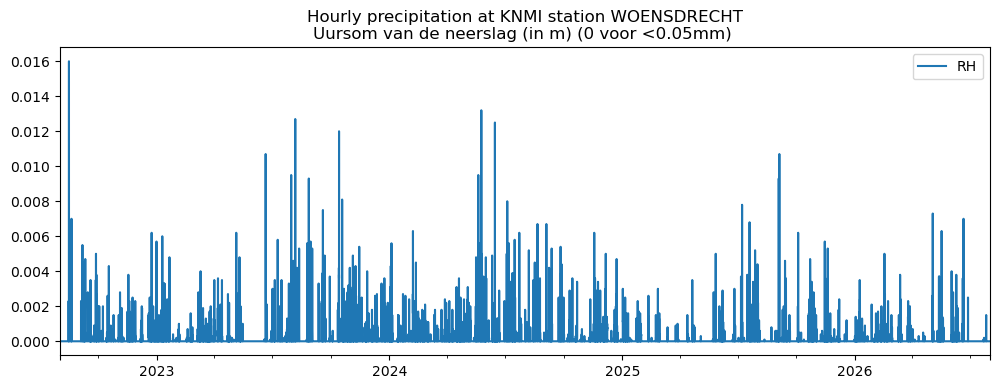

In [5]:
precip.plot(figsize=(12, 4), title=f"Hourly precipitation at KNMI station {precip.meta['location']}\n{precip.meta['RH'].split(r'/')[0]}")

Analyse van de verschillende jaren. Gekozen om cummulatieve neerslag sinds 1 augustus te plotten, tot 31 juli jaar er op. In die periode stijgt namelijk de grondwaterstand in de dijk.

In [6]:
precip_df = precip.copy()
precip_df['date'] = precip_df.index
precip_df['year'] = precip_df['date'].dt.year
precip_df['month'] = precip_df['date'].dt.month
precip_df['season_year'] = precip_df['year']
precip_df.loc[precip_df['month'] < 8, 'season_year'] -= 1
precip_df['cumulative'] = precip_df.groupby('season_year')[precip.columns[0]].cumsum()

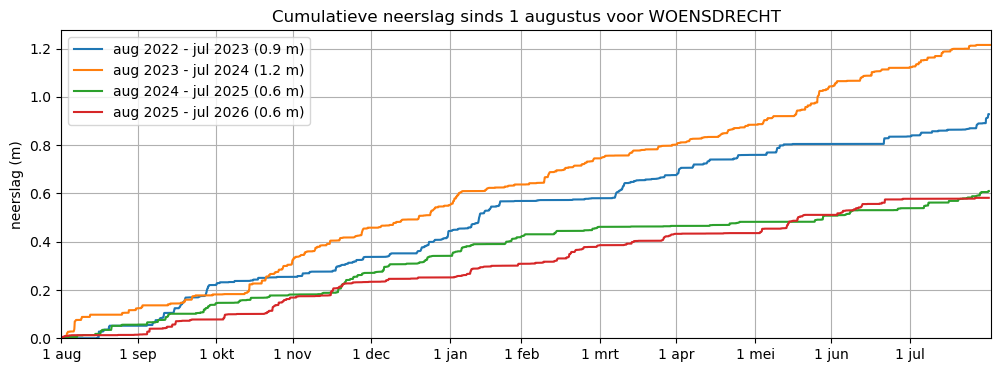

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
for year, group in precip_df.groupby('season_year'):
    days_since_start = (group['date'] - group['date'].iloc[0]).dt.total_seconds() / 86400
    if year < 2026:
        ax.plot(days_since_start, group['cumulative'], label=f'aug {year} - jul {year+1} ({group["cumulative"].iloc[-1]:.1f} m)')
ax.set_xticks([0, 30, 61, 91, 122, 153, 181, 212, 242, 273, 303, 334])
ax.set_xticklabels(['1 aug', '1 sep', '1 okt', '1 nov', '1 dec', '1 jan', '1 feb', '1 mrt', '1 apr', '1 mei', '1 jun', '1 jul'])

ax.set_title(f'Cumulatieve neerslag sinds 1 augustus voor {precip.meta['location']}')
ax.set_ylabel('neerslag (m)')
ax.legend()
ax.set_xlim(0, 366)
ax.set_ylim(bottom=0)
ax.grid(True)

Voor normomstandigheden van waterkeringen is langdurige regen relevant. Want dan zijn omstandigheden enigszins vergelijkbaar met overslag door golven.

Daarom grafiek maken met aantal uur regen per dag (blauw). Daarin met oranaje aangegeven wanneer er ook veel neerslag valt. Vervolgens met de verticale lijn aangegeven of dat ook in de natte periode van het jaar valt.

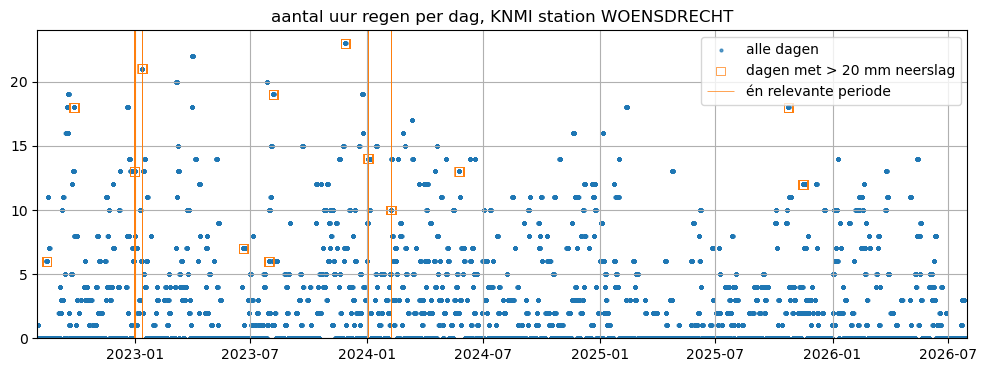

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ylims = [0, 24]

# plot het aantal uur dat het per dag regent
dt_hours = precip_df.index.to_series().diff().dt.total_seconds().div(3600).fillna(1.0)
precip_df['hours_of_rain'] = ((precip_df[precip.columns[0]] > 0).astype(float) * dt_hours).groupby(precip_df.index.normalize()).transform('sum')
ax.scatter(x=precip_df['date'], y=precip_df['hours_of_rain'], s=4, alpha=0.7, label='alle dagen')

# natte dagen
precip_threshold = 20 / 1000 
precip_df_filtered = precip_df[precip_df[precip.columns[0]].groupby(precip_df.index.normalize()).transform('sum') > precip_threshold]
ax.scatter(
    x=precip_df_filtered['date'],
    y=precip_df_filtered['hours_of_rain'],
    s=40,
    marker='s', facecolors='none', edgecolors='tab:orange',  linewidths=0.5,
    label=f'dagen met > {precip_threshold * 1000:.0f} mm neerslag'
)

# in natte periode
precip_df_filtered_highlight = precip_df_filtered[(precip_df_filtered['month'].isin([1, 2, 3, 12]))]
ax.vlines(x=precip_df_filtered_highlight['date'], ymin=ylims[0], ymax=ylims[1], color='tab:orange', linewidth=0.5, label=f'én relevante periode')

# layout
ax.set_xlim([precip_df['date'].min(), precip_df['date'].max()])
ax.set_ylim(ylims)
ax.set_title(f'aantal uur regen per dag, KNMI station {precip.meta['location']}')
ax.grid(True)
ax.legend()


## Conclusie voor neerslag

- periode aug 2022-juli 2023; en aug 2023-juli 2024 zijn het natst (van de beschikbare jaren met waargenomen grondwaterstanden)
- in beide periodes liggen rond de jaarwisseling twee dagen met meer dan 20 mm neerslag

# Peilbuizen

In [9]:
obs = lmkw.json_to_hpd(
    r'c:\data\python\cloned\N27-2\data\obs\json\json.zip'
)

INFO:root:JSON files read: 96
INFO:root:Obs created: 96
INFO:root:ObsCollection created with 96 Obs objects


In [10]:
obs.head()

,x,y,location,filename,source,unit,tube_nr,screen_top,screen_bottom,ground_level,...,distance_to_ref,filter_letter,tube_bottom,traject,timeseries_id,in_analysis,remark_obs,raai_plot,plot_dp,plot_x
name,,,,,,,,,,,,,,,,,,,,,
Os_dp1000-0_BIT_H,64107.184,394021.779,19B_011,[\\ws.local\share\wk\ProjectenWaterkeringen\Be...,Diver CSV,,10,-1.071000,-2.071000,-0.471,...,-19.202480,H,-3.071000,"onbekend, niet gegeven in Boring2013",19B_011H,NaN,"Diver in sept 2024 gestopt, geheugen vol. Uitg...",Os_1000.0,Os_1000.0,0.797520
Os_dp1000-0_BUB_L,64103.114,393993.713,B212,\\ws.local\share\wk\ProjectenWaterkeringen\Beh...,Waterschap Scheldestromen PB meting Excel,,30,-12.680001,-13.680001,3.400,...,9.112425,L,-14.630001,"onbekend, niet gegeven in Boring2013",B212L,NaN,NaN,Os_1000.0,Os_1000.0,69.112425
Os_dp1005-0_BUB_L,64601.541,393947.788,B213,\\ws.local\share\wk\ProjectenWaterkeringen\Beh...,Waterschap Scheldestromen PB meting Excel,,30,-10.620000,-11.620000,3.420,...,11.171383,L,-12.570000,"onbekend, niet gegeven in Boring2013",B213L,NaN,NaN,Os_1005.0,Os_1005.0,71.171383
Os_dp1010-0_BIT_H,65102.304,393932.987,19B_013,[\\ws.local\share\wk\ProjectenWaterkeringen\Be...,Diver CSV,,10,-0.764000,-1.764000,2.236,...,-19.020439,H,-2.764000,"onbekend, niet gegeven in Boring2013",19B_013H,NaN,NaN,Os_1010.0,Os_1010.0,0.979561
Os_dp1012-0_KR_H,65164.774,393753.562,23B_043,[\\ws.local\share\wk\ProjectenWaterkeringen\Be...,Diver CSV,,10,3.290000,2.290000,7.092,...,-1.024242,H,1.290000,"onbekend, niet gegeven in Boring2013",23B_043H,NaN,NaN,Os_1012.0,Os_1012.0,18.975758


In [11]:
col_gwl = 'gwl_mnap'
col_temp = 'temp_oC'
col_manual_obs = 'manual_gwl_mnap'
col_dry = 'tube_dry'

INFO:hydropandas.extensions.plots:created sectionplot -> Os_dp1000-0_BIT_H


INFO:hydropandas.extensions.plots:created sectionplot -> Os_dp1000-0_BUB_L
INFO:hydropandas.extensions.plots:created sectionplot -> Os_dp1005-0_BUB_L
INFO:hydropandas.extensions.plots:created sectionplot -> Os_dp1010-0_BIT_H
INFO:hydropandas.extensions.plots:created sectionplot -> Os_dp1012-0_KR_H
INFO:hydropandas.extensions.plots:created sectionplot -> Os_dp1015-0_BUB_L
INFO:hydropandas.extensions.plots:created sectionplot -> Os_dp1020-0_BIT_H
INFO:hydropandas.extensions.plots:created sectionplot -> Os_dp1020-0_KR_H
INFO:hydropandas.extensions.plots:created sectionplot -> Os_dp1025-0_BUB_L
INFO:hydropandas.extensions.plots:created sectionplot -> Os_dp1028-0_BIT_H


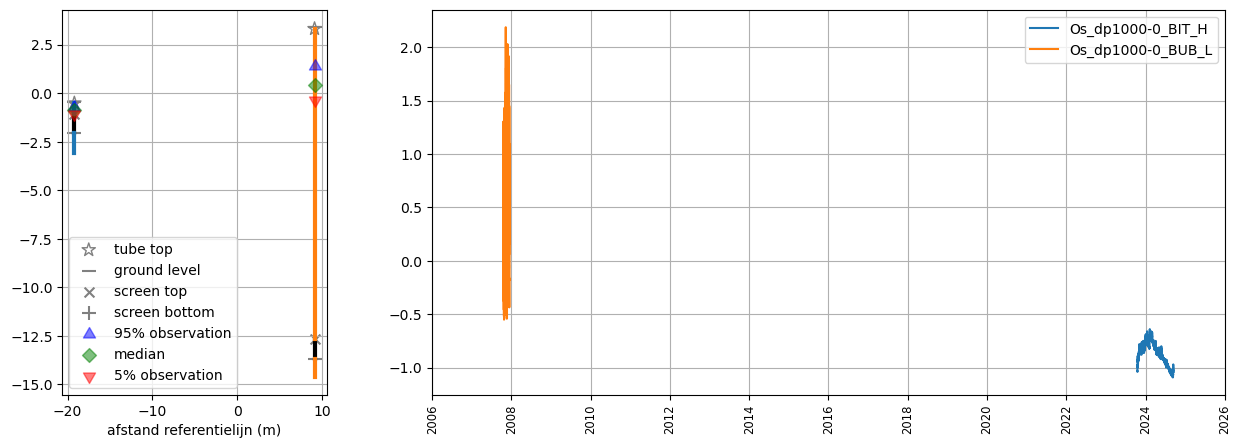

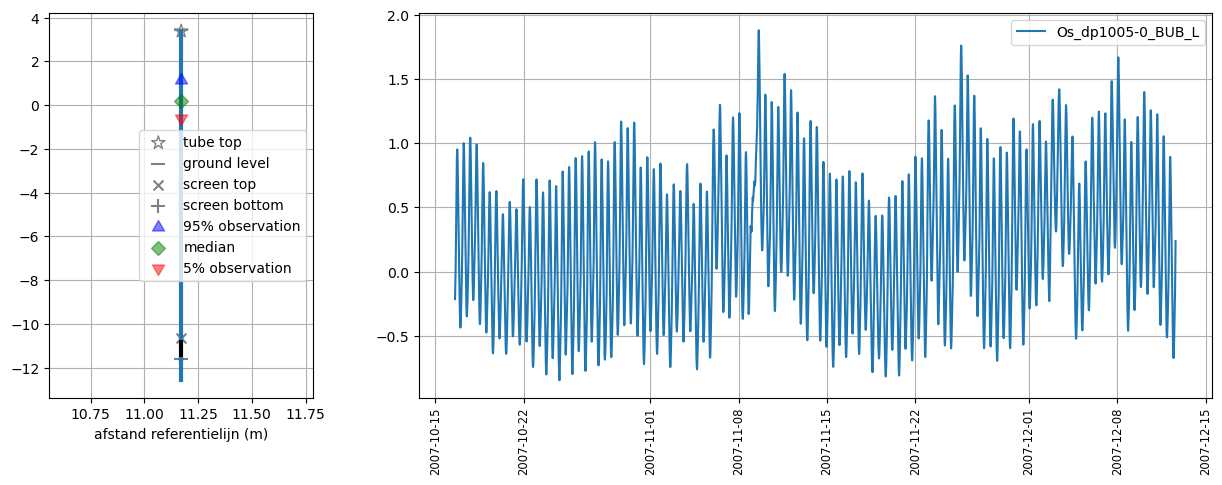

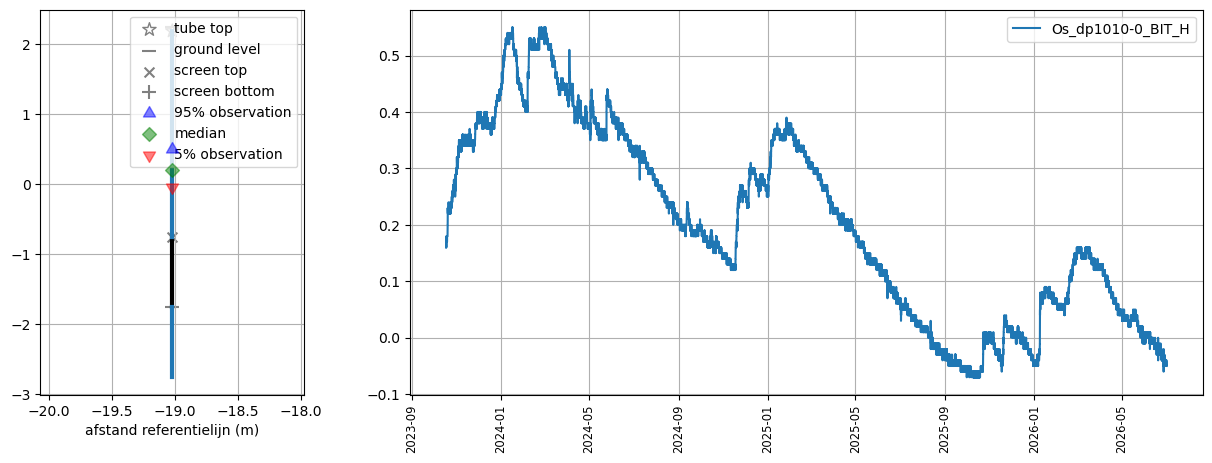

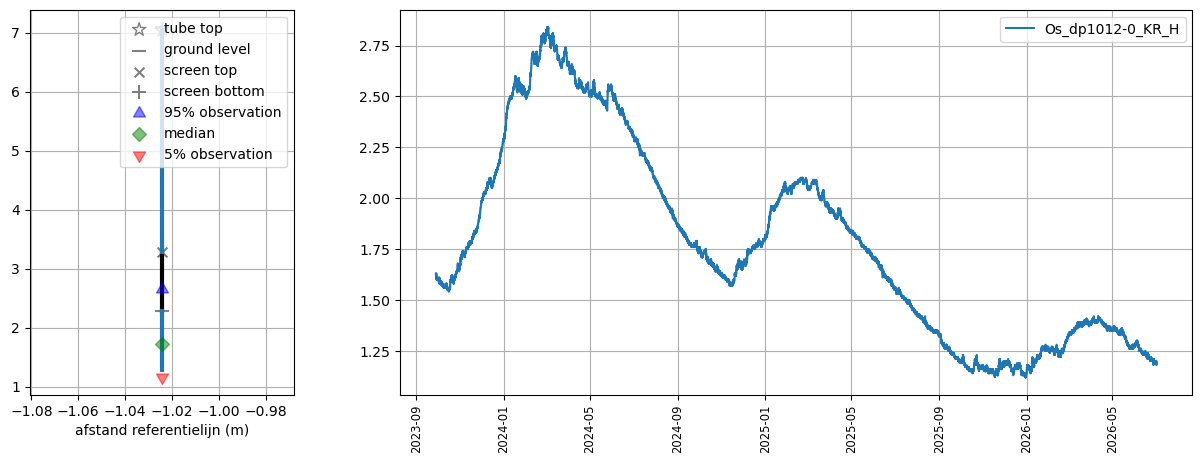

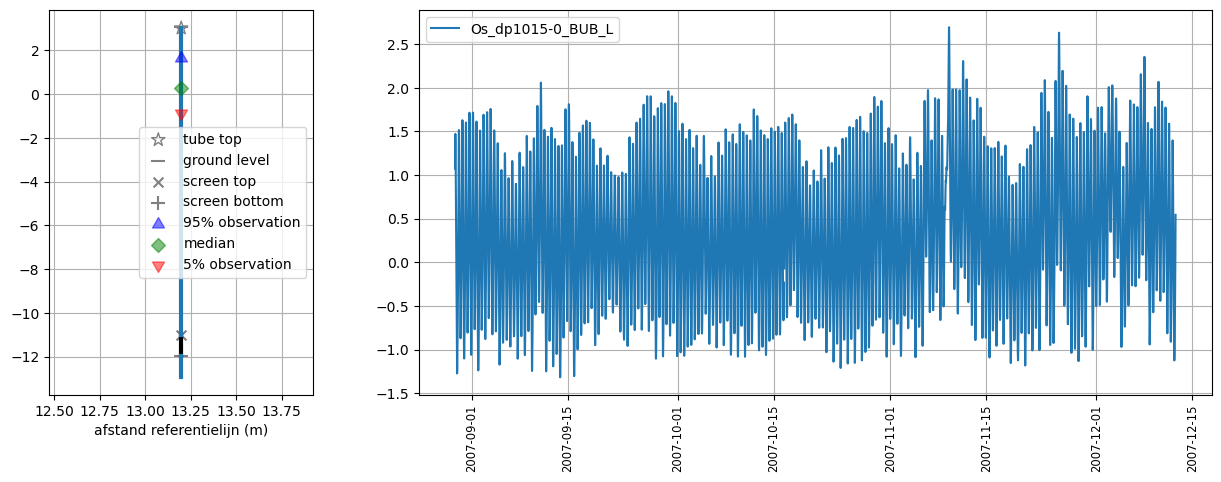

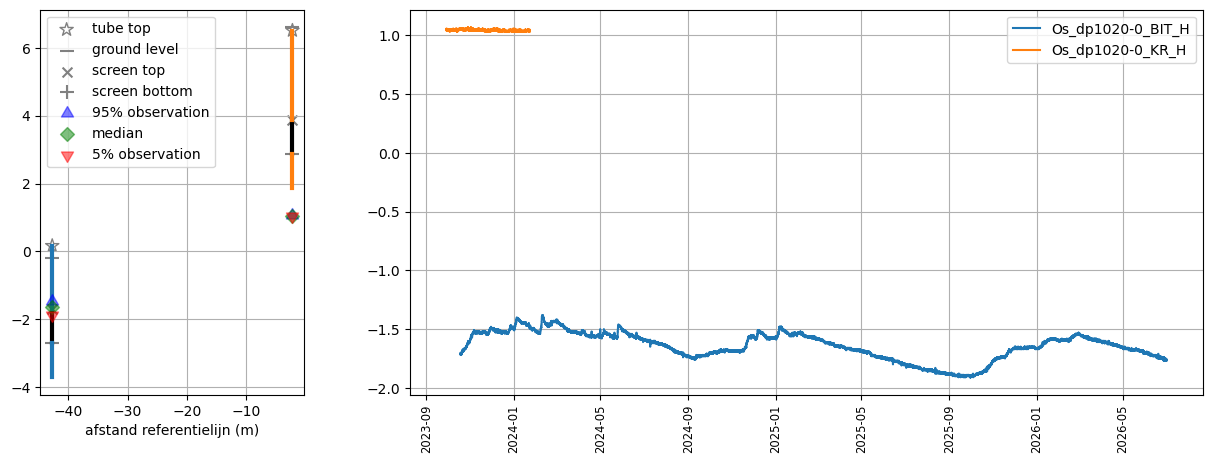

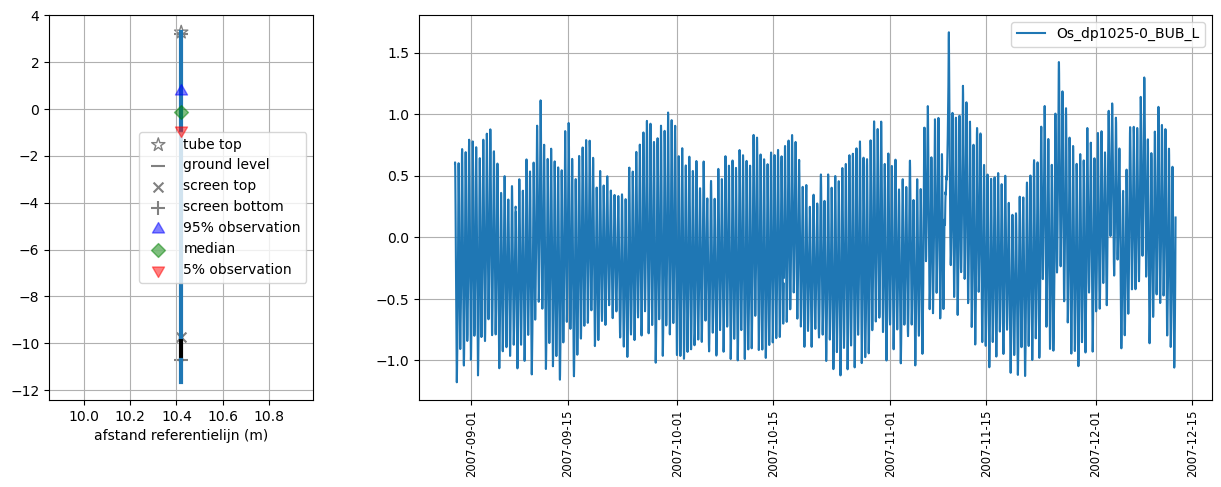

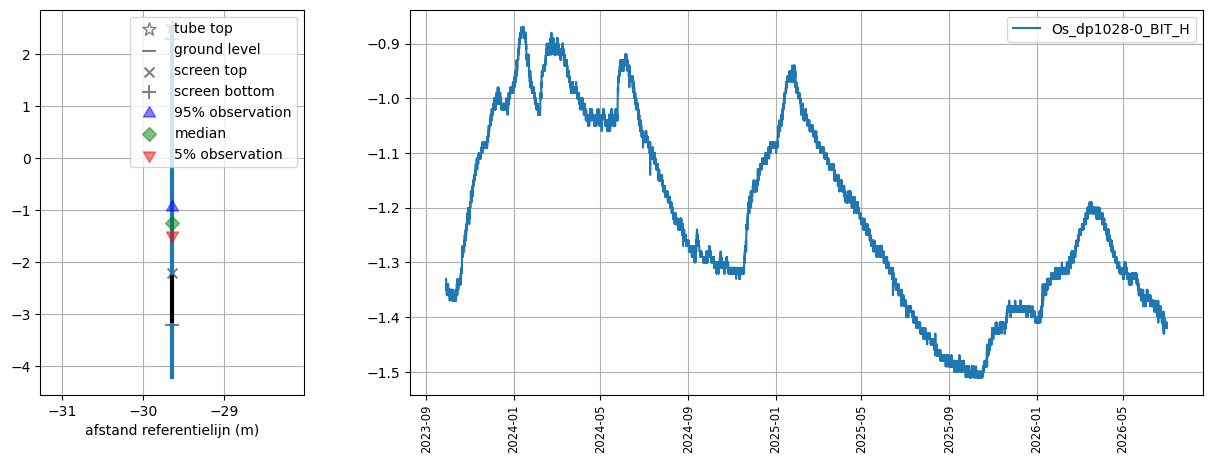

In [15]:
for raai, oc_raai in obs.iloc[:10].groupby('raai_plot'):
    fig, axes = oc_raai.plots.section_plot(
        cols=[col_gwl],
        # tmin='2018-02-09',
        # tmax='2018-04-25',
        # section_colname_x='plot_x',
        section_colname_x='distance_to_ref',
        section_label_x='afstand referentielijn (m)',
        plot_well_layout_markers=True,
    )

In [16]:
# TODO: cummulatieve neerslag plotten
# TODO: natte momenten plotten